# Practical 03 — Linear Regression and Residual Error

**Laboratory:** M.Tech Machine Learning  
**Kernel:** `ml-lab-kernel`  
**Syllabus:** *Implement Linear Regression and compute residual error.*  
**Benchmark:** Medical Cost Personal data — predict `charges` (USD).

### Lab map

```text
[1] Colab header  →  [2] DATASET CONFIG (path, features, target)
        ↓
[3] Load CSV  →  [4] HAND table (m, c, ŷ, e, SS_res, SS_tot, R²)
        ↓
[5] OLS / GD / Gauss–Markov theory  →  [6] Leakage-safe sklearn fit
        ↓
[7] 4-panel residual diagnostics  →  [8] Viva  →  [9] Conclusion
```

### Learning outcomes

1. Compute slope $m$, intercept $c$, fitted $\hat{y}$, residuals $e_i$, $SS_{\mathrm{res}}$, $SS_{\mathrm{tot}}$, and $R^2$ **by hand** on 5 rows.
2. State the **OLS normal equations** and a **gradient-descent** update.
3. List the **four Gauss–Markov / inference assumptions** used in this lab.
4. Fit `LinearRegression` with **`train_test_split`** and **train-only** `StandardScaler`.
5. Report MAE, MSE, RMSE, $R^2$, **adjusted** $R^2$, and read a **4-panel residual figure**.

> **Why this matters:** regression is not “draw a line.” It is a **loss**, a **solver**, and a **checklist of assumptions**. If you scale using the test set or skip residual plots, the $R^2$ on the slide is theatre.


## Colab 1-click header (skip upload on a campus PC)

**Google Colab**

1. Runtime → Run all (or run this cell, then **DATASET CONFIG**).
2. Own CSV: **upload** when prompted, or mount Drive and set `COLAB_DRIVE_CSV`.
3. No file: loader uses a public insurance URL, then sklearn housing as last resort.

**Local Jupyter (`ml-lab-kernel`)** — this cell only reports the runtime; packages should already be installed.


In [1]:
# --- Colab / local compatibility (safe to run everywhere) ---
from __future__ import annotations

import sys
from pathlib import Path

from IPython.display import HTML, display

IN_COLAB = "google.colab" in sys.modules


def _banner(text: str, bg: str = "#1e3a5f") -> None:
    display(
        HTML(
            f'<div style="background:{bg};color:#fff;padding:10px 14px;'
            f"border-radius:8px;font-family:Segoe UI,sans-serif;"
            f'font-weight:600;margin:6px 0;">{text}</div>'
        )
    )


def _why(text: str) -> None:
    display(
        HTML(
            f'<div style="background:#f0f9ff;border-left:4px solid #0369a1;'
            f"padding:10px 14px;border-radius:4px;font-family:Segoe UI,sans-serif;"
            f'margin:8px 0;"><b>Why this matters.</b> {text}</div>'
        )
    )


def _rule(title: str = "") -> None:
    bar = "=" * 72
    if title:
        print(f"\n{bar}\n {title}\n{bar}")
    else:
        print(bar)


_banner("0 · Runtime")
print(f"Colab detected: {IN_COLAB}  |  Python {sys.version.split()[0]}")

if IN_COLAB:
    get_ipython().run_line_magic(
        "pip", "install -q numpy pandas matplotlib seaborn scikit-learn scipy"
    )  # why: Colab VMs start empty; campus PCs already have the lab venv
    print("Colab: packages checked via %pip.")
else:
    print("Local kernel: skipping %pip. Use ml-lab-kernel / the lab venv.")


def colab_upload_to(dest: Path) -> Path | None:
    """1-click CSV upload on Colab."""
    if not IN_COLAB:
        return None
    from google.colab import files  # type: ignore

    uploaded = files.upload()  # why: Colab has no ./data folder until you add one
    if not uploaded:
        return None
    name, blob = next(iter(uploaded.items()))
    dest = dest if dest.suffix else dest / name
    dest.parent.mkdir(parents=True, exist_ok=True)
    dest.write_bytes(blob)
    print(f"Saved upload -> {dest}")
    return dest


def colab_mount_drive() -> Path | None:
    if not IN_COLAB:
        return None
    from google.colab import drive  # type: ignore

    drive.mount("/content/drive")  # why: reuse a CSV already stored in Drive
    root = Path("/content/drive/MyDrive")
    return root if root.exists() else None


Colab detected: False  |  Python 3.14.0
Local kernel: skipping %pip. Use ml-lab-kernel / the lab venv.


## DATASET CONFIG BLOCK — the only cell most beginners edit

```text
  DATA_PATH ──────────► CSV on disk
  FEATURE_COLUMNS ────► numeric predictors used in X
  TARGET_COLUMN ──────► the number you want to predict (y)
  DROP_COLUMNS ───────► IDs / names to ignore
```

**Lab default:** medical insurance. `charges` is the target. Start with **numeric** features only (`age`, `bmi`, `children`). Categorical columns (`sex`, `smoker`, `region`) need encoding — later labs.

> **Why this matters:** the model does not guess which column is the bill. A wrong `TARGET_COLUMN` trains the wrong experiment. Non-numeric features in `FEATURE_COLUMNS` will crash `StandardScaler`.


In [2]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  DATASET CONFIG — edit this block to swap CSV / features / target    ║
# ╚══════════════════════════════════════════════════════════════════════╝

DATA_PATH = "data/medical_insurance.csv"
TARGET_COLUMN = "charges"  # why: this is y — annual medical cost (USD)
FEATURE_COLUMNS = ["age", "bmi", "children"]  # why: numeric only for this lab's scaler + OLS
DROP_COLUMNS: list[str] = []  # why: drop IDs/names before building X

# Colab-only (ignored locally)
COLAB_DRIVE_CSV = None  # e.g. "/content/drive/MyDrive/insurance.csv"
COLAB_OFFER_UPLOAD = True

from pathlib import Path as _Path

_rule("DATASET CONFIG")
print(f"DATA_PATH         = {DATA_PATH}")
print(f"TARGET_COLUMN     = {TARGET_COLUMN}")
print(f"FEATURE_COLUMNS   = {FEATURE_COLUMNS}")
print(f"DROP_COLUMNS      = {DROP_COLUMNS}")
_p = _Path(DATA_PATH)
print(f"local CSV exists: {_p.is_file()}  ({_p.resolve() if _p.exists() else _p})")



 DATASET CONFIG
DATA_PATH         = data/medical_insurance.csv
TARGET_COLUMN     = charges
FEATURE_COLUMNS   = ['age', 'bmi', 'children']
DROP_COLUMNS      = []
local CSV exists: True  (D:\LiamCodes\parul-mtech-coding\ml-practical\03_Linear_Regression\data\medical_insurance.csv)


## 0. Environment, seed, and large high-DPI figures


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy import stats
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42  # why: any fixed int is fine; 42 is the lab convention
np.random.seed(SEED)

plt.rcParams.update(
    {
        "figure.figsize": (14, 7),  # why: large on-screen / projection figures
        "figure.dpi": 140,          # why: sharp saved notebook outputs
        "savefig.dpi": 300,         # why: print-quality PNG/PDF
        "font.size": 13,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 13,
        "figure.titlesize": 18,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,         # why: light grid; points stay the focus
    }
)
pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 1000)
pd.set_option("display.max_colwidth", 48)
sns.set_theme(style="whitegrid", palette="colorblind")

_banner("0 · Libraries")
print("Python", sys.version.split()[0])
print("numpy", np.__version__, "| pandas", pd.__version__, "| sklearn LinearRegression")
print("SEED =", SEED)


Python 3.14.0
numpy 2.5.2 | pandas 3.0.5 | sklearn LinearRegression
SEED = 42


## 1. Load the configured table (local → URL → sklearn housing)

| Priority | Source |
|----------|--------|
| 1 | `DATA_PATH` on disk |
| 2 | Colab Drive / upload |
| 3 | Lantz `insurance.csv` GitHub raw |
| 4 | `fetch_california_housing` (different domain — log the origin) |


In [4]:
INSURANCE_URL = (
    "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/"
    "master/insurance.csv"
)


def _from_california() -> pd.DataFrame:
    bunch = fetch_california_housing(as_frame=True)  # why: last-resort numeric table
    frame = bunch.frame.copy()
    print("WARNING: using California housing — domain ≠ medical insurance. Log this origin.")
    return frame


def load_primary() -> tuple[pd.DataFrame, str]:
    path = Path(DATA_PATH)
    if IN_COLAB and COLAB_DRIVE_CSV:
        colab_mount_drive()
        drive_p = Path(COLAB_DRIVE_CSV)
        if drive_p.is_file():
            return pd.read_csv(drive_p), "gdrive"
    if IN_COLAB and COLAB_OFFER_UPLOAD and not path.is_file():
        saved = colab_upload_to(path)
        if saved is not None:
            return pd.read_csv(saved), "colab_upload"
    if path.is_file():
        return pd.read_csv(path), "local"  # why: version-controlled lab CSV
    try:
        return pd.read_csv(INSURANCE_URL), "url"
    except Exception as exc:
        print("URL failed:", type(exc).__name__, exc)
        return _from_california(), "sklearn_housing"


df, load_origin = load_primary()
for col in DROP_COLUMNS:
    if col in df.columns:
        df = df.drop(columns=[col])

if TARGET_COLUMN not in df.columns:
    raise KeyError(
        f"TARGET_COLUMN={TARGET_COLUMN!r} not in {list(df.columns)}. Fix CONFIG."
    )
missing = [c for c in FEATURE_COLUMNS if c not in df.columns]
if missing:
    raise KeyError(f"FEATURE_COLUMNS not in CSV: {missing}. Columns: {list(df.columns)}")

_banner("1 · Loaded table")
print(f"origin = {load_origin} | shape = {df.shape}")
print(f"features X = {FEATURE_COLUMNS}")
print(f"target   y = {TARGET_COLUMN}")
display(df.head(5).style.set_caption("Configured table (first 5 rows)").format(precision=3))


origin = local | shape = (1338, 7)
features X = ['age', 'bmi', 'children']
target   y = charges


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.924
1,18,male,33.770,1,no,southeast,1725.552
2,28,male,33.000,3,no,southeast,4449.462
3,33,male,22.705,0,no,northwest,21984.471
4,32,male,28.880,0,no,northwest,3866.855


## 2. Step-by-step manual OLS (5-row toy — lab-manual standard)

This table is **not** insurance. It is a calculator exercise you can repeat in an exam.

| $i$ | $x_i$ (hours studied) | $y_i$ (score) |
|----:|----------------------:|--------------:|
| 1 | 1 | 2 |
| 2 | 2 | 3 |
| 3 | 3 | 5 |
| 4 | 4 | 4 |
| 5 | 5 | 6 |

### Recipe (simple linear regression)

1. Means $\bar{x}=\frac{1}{n}\sum x_i$, $\bar{y}=\frac{1}{n}\sum y_i$.
2. Deviations $d_{x,i}=x_i-\bar{x}$, $d_{y,i}=y_i-\bar{y}$.
3. **Slope** and **intercept**
   $$
   m
   =\frac{\sum d_{x,i}d_{y,i}}{\sum d_{x,i}^{2}}
   =\frac{\mathrm{SP}_{xy}}{\mathrm{SS}_x},
   \qquad
   c=\bar{y}-m\bar{x}.
   $$
4. Fitted values $\hat{y}_i=c+m x_i$.
5. Residuals $e_i=y_i-\hat{y}_i$.
6. **Sums of squares** and **$R^2$**
   $$
   SS_{\mathrm{res}}=\sum_i e_i^{2},
   \quad
   SS_{\mathrm{tot}}=\sum_i (y_i-\bar{y})^{2},
   \quad
   R^{2}=1-\frac{SS_{\mathrm{res}}}{SS_{\mathrm{tot}}}.
   $$

> **Why this matters:** $R^2$ is *not* “accuracy.” It is the fraction of variance in $y$ that the line explains. $R^2=1$ means every point sits on the line ($SS_{\mathrm{res}}=0$). $R^2=0$ means the line is no better than predicting $\bar{y}$.


In [5]:
_banner("2 · Manual 5-row OLS")

x = np.array([1.0, 2.0, 3.0, 4.0, 5.0])  # why: small integers so arithmetic is exam-friendly
y = np.array([2.0, 3.0, 5.0, 4.0, 6.0])
n = len(x)

xbar = x.mean()  # why: mean uses n, not n-1
ybar = y.mean()
dx = x - xbar
dy = y - ybar
sp = np.sum(dx * dy)
ssx = np.sum(dx**2)

m = sp / ssx  # why: OLS slope = SP_xy / SS_x
c = ybar - m * xbar  # why: the line must pass through (x̄, ȳ)
yhat = c + m * x
e = y - yhat  # why: residual = leftover after the line
ss_res = np.sum(e**2)
ss_tot = np.sum((y - ybar) ** 2)
r2_hand = 1.0 - ss_res / ss_tot  # why: 1 = perfect; 0 = no better than the mean

work = pd.DataFrame(
    {
        "i": np.arange(1, n + 1),
        "x": x,
        "y": y,
        "ŷ = c + m x": yhat,
        "e = y − ŷ": e,
        "e²": e**2,
        "(y − ȳ)²": (y - ybar) ** 2,
    }
)
_why(
    "If a residual is positive, the line under-predicted that row. "
    "If negative, it over-predicted. OLS makes the sum of squared residuals as small as possible."
)
display(
    work.style.format(precision=4)
    .background_gradient(subset=["e = y − ŷ"], cmap="coolwarm")
    .set_caption("Worked table: fitted values and residuals")
)

summary = pd.DataFrame(
    {
        "quantity": [
            "n",
            "x̄",
            "ȳ",
            "SP_xy",
            "SS_x",
            "slope m",
            "intercept c",
            "SS_res = Σ e²",
            "SS_tot = Σ (y−ȳ)²",
            "R² (hand)",
        ],
        "value": [n, xbar, ybar, sp, ssx, m, c, ss_res, ss_tot, r2_hand],
    }
)
display(summary.style.format({"value": "{:.6f}"}).set_caption("Totals for the lab record"))

# NumPy verification: polyfit degree 1 is OLS for y ≈ c + m x
m_np, c_np = np.polyfit(x, y, deg=1)  # why: returns [m, c] for a straight line
X1 = np.column_stack([np.ones(n), x])  # why: intercept column of ones
beta_lstsq, *_ = np.linalg.lstsq(X1, y, rcond=None)  # why: stable OLS (QR/SVD), not inv()
r2_np = 1.0 - np.sum((y - (c_np + m_np * x)) ** 2) / ss_tot

check = pd.DataFrame(
    {
        "quantity": ["slope m", "intercept c", "R²"],
        "hand": [m, c, r2_hand],
        "numpy.polyfit / lstsq": [m_np, c_np, r2_np],
        "|hand − numpy|": [abs(m - m_np), abs(c - c_np), abs(r2_hand - r2_np)],
    }
)
display(check.style.format(precision=10).set_caption("Verification vs NumPy (should be ~ 0)"))
assert np.allclose([m, c], [m_np, c_np])
assert np.allclose(beta_lstsq, [c, m])
print("Hand m, c, R² MATCH NumPy polyfit and lstsq.")
print(f"lstsq β = [c, m] = {beta_lstsq}")


,i,x,y,ŷ = c + m x,e = y − ŷ,e²,(y − ȳ)²
0,1,1.0000,2.0000,2.2000,-0.2000,0.0400,4.0000
1,2,2.0000,3.0000,3.1000,-0.1000,0.0100,1.0000
2,3,3.0000,5.0000,4.0000,1.0000,1.0000,1.0000
3,4,4.0000,4.0000,4.9000,-0.9000,0.8100,0.0000
4,5,5.0000,6.0000,5.8000,0.2000,0.0400,4.0000


,quantity,value
0,n,5.000000
1,x̄,3.000000
2,ȳ,4.000000
3,SP_xy,9.000000
4,SS_x,10.000000
5,slope m,0.900000
6,intercept c,1.300000
7,SS_res = Σ e²,1.900000
8,SS_tot = Σ (y−ȳ)²,10.000000
9,R² (hand),0.810000


,quantity,hand,numpy.polyfit / lstsq,|hand − numpy|
0,slope m,0.9000000000,0.9000000000,0.0000000000
1,intercept c,1.3000000000,1.3000000000,0.0000000000
2,R²,0.8100000000,0.8100000000,0.0000000000


Hand m, c, R² MATCH NumPy polyfit and lstsq.
lstsq β = [c, m] = [1.3 0.9]


## 3. Theory: OLS, gradient descent, Gauss–Markov

### 3.1 Multiple regression and the normal equations

With design matrix $X\in\mathbb{R}^{n\times(p+1)}$ (first column all ones) and target $y\in\mathbb{R}^{n}$:

$$
y = X\beta + \varepsilon,
\qquad
\hat{y}=X\hat\beta,
\qquad
e=y-\hat{y}.
$$

OLS minimises $J(\beta)=\|y-X\beta\|_2^{2}$. Setting the gradient to zero gives the **normal equations**

$$
X^{\top}X\,\hat\beta = X^{\top}y.
$$

If $X^{\top}X$ is invertible (full column rank),

$$
\hat\beta = (X^{\top}X)^{-1} X^{\top} y.
$$

**In code we do not invert.** We solve $A\hat\beta=b$ with `np.linalg.solve` or `lstsq` (QR/SVD). Explicit `inv` squares the condition number.

### 3.2 Batch gradient descent on MSE

For large $n$, iterate on the mean squared error

$$
J(\beta)=\frac{1}{2n}\|X\beta-y\|_2^{2},
\qquad
\nabla J(\beta)=\frac{1}{n}X^{\top}(X\beta-y),
\qquad
\beta \leftarrow \beta - \eta\,\nabla J(\beta).
$$

$\eta>0$ is the **learning rate**. Too large → divergence; too small → slow crawl. Scaling features makes the bowl of $J$ rounder, so GD is less fussy — that is why we use `StandardScaler` **after** the train/test split.

### 3.3 Four assumptions used in this lab

| # | Name | Meaning | If it fails |
|---|------|---------|-------------|
| 1 | **Linearity** | $\mathbb{E}[y\mid x]$ is a straight line (or hyperplane) in the features | Curve leftover in residuals vs fitted |
| 2 | **Homoscedasticity** | Residual variance is constant (no fan shape) | Unequal spread; SEs wrong |
| 3 | **Normality of residuals** | $e_i$ look Gaussian (for $t$ / $F$ inference) | Q–Q bows; p-values shaky |
| 4 | **Independence** | Errors are not clustered in time/groups | Adjacent residuals correlated |

Gauss–Markov (BLUE) needs linearity, exogeneity, and spherical errors; **normality is extra** for exact small-sample inference. We still plot the Q–Q panel because the syllabus asks you to *look* at residual shape.

> **Why this matters:** a high $R^2$ with a curved residual plot means you fitted the **wrong shape**. Always look at the four panels before trusting a slope.


In [6]:
_banner("3 · GD vs OLS on the same 5-row toy")

# Design with intercept
X_toy = np.column_stack([np.ones(n), x])
beta_ols = np.linalg.solve(X_toy.T @ X_toy, X_toy.T @ y)  # why: solve, not inv

eta = 0.08  # why: small enough to converge on this tiny, well-scaled toy
n_steps = 400
beta_gd = np.zeros(2)
history = []
for t in range(n_steps):
    grad = (X_toy.T @ (X_toy @ beta_gd - y)) / n  # why: ∇ of (1/2n)||Xβ−y||²
    beta_gd = beta_gd - eta * grad
    if t % 80 == 0 or t == n_steps - 1:
        history.append((t + 1, beta_gd.copy(), float(np.mean((X_toy @ beta_gd - y) ** 2))))

hist_df = pd.DataFrame(history, columns=["step", "beta", "MSE"])
hist_df["c_gd"] = [b[0] for b in hist_df["beta"]]
hist_df["m_gd"] = [b[1] for b in hist_df["beta"]]
display(
    hist_df[["step", "c_gd", "m_gd", "MSE"]]
    .style.format(precision=5)
    .set_caption("Gradient descent path (should approach OLS)")
)
cmp = pd.DataFrame(
    {"OLS (normal eq.)": beta_ols, "GD (final)": beta_gd},
    index=["intercept c", "slope m"],
)
display(cmp.style.format("{:.6f}").set_caption("Closed-form OLS vs GD"))
print("||β_GD − β_OLS|| =", float(np.linalg.norm(beta_gd - beta_ols)))


,step,c_gd,m_gd,MSE
0,1,0.32000,1.10400,0.59866
1,81,0.97611,0.98971,0.39909
2,161,1.19103,0.93018,0.38216
3,241,1.26334,0.91016,0.38024
4,321,1.28766,0.90342,0.38003
5,400,1.29579,0.90117,0.38000


,OLS (normal eq.),GD (final)
intercept c,1.300000,1.295793
slope m,0.900000,0.901165


||β_GD − β_OLS|| = 0.004365856734359158


## 4. Leakage-safe sklearn baseline

```text
WRONG:  scale all rows  →  then split     (test means leaked into X)
RIGHT:  split first
        fit StandardScaler on TRAIN only
        transform TEST with frozen μ, σ
        LinearRegression.fit on scaled TRAIN
```

**Adjusted $R^2$** (penalty for extra features; $p$ = number of predictors, not counting intercept):

$$
R^{2}_{\mathrm{adj}}
= 1 - (1-R^{2})\frac{n-1}{n-p-1}.
$$

> **Why this matters:** adding junk columns can raise $R^2$ on the training set. Adjusted $R^2$ and **test** RMSE are the honest numbers.


In [7]:
_banner("4 · Split, scale (train only), LinearRegression")

work = df.dropna(subset=FEATURE_COLUMNS + [TARGET_COLUMN]).copy()
X = work[FEATURE_COLUMNS].to_numpy(dtype=np.float64)
y = work[TARGET_COLUMN].to_numpy(dtype=np.float64)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,     # why: 20% hold-out — enough to test, most rows still train
    random_state=SEED,  # why: same split every re-run so lab numbers match
    shuffle=True,       # why: do not test only the last 20% of a sorted file
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)  # why: learn μ, σ from TRAIN only
X_test_s = scaler.transform(X_test)        # why: reuse TRAIN μ, σ — no leakage

model = LinearRegression()  # why: closed-form OLS / SVD — no learning-rate to tune
model.fit(X_train_s, y_train)

yhat_tr = model.predict(X_train_s)
yhat_te = model.predict(X_test_s)


def regression_report(y_true: np.ndarray, y_pred: np.ndarray, split: str, p: int) -> dict:
    n_ = len(y_true)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = float(np.sqrt(mse))  # why: RMSE in the same units as y
    r2 = r2_score(y_true, y_pred)
    adj = 1.0 - (1.0 - r2) * (n_ - 1) / (n_ - p - 1)  # why: penalise extra predictors
    return {
        "split": split,
        "n": n_,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "Adj_R2": adj,
    }


p = X_train.shape[1]
metrics = pd.DataFrame(
    [
        regression_report(y_train, yhat_tr, "train", p),
        regression_report(y_test, yhat_te, "test", p),
    ]
)
_why(
    "Compare TRAIN vs TEST. If train R² is much larger and test RMSE is much worse, "
    "the line memorised noise (overfit) or the split is unlucky."
)
display(
    metrics.style.format(
        {"MAE": "{:.2f}", "MSE": "{:.2f}", "RMSE": "{:.2f}", "R2": "{:.4f}", "Adj_R2": "{:.4f}"}
    )
    .background_gradient(subset=["R2", "Adj_R2"], cmap="Greens")
    .set_caption("Hold-out metrics (test row is the one that counts)")
)

coef_tbl = pd.DataFrame(
    {"feature": FEATURE_COLUMNS, "weight (on scaled X)": model.coef_}
).sort_values("weight (on scaled X)", key=np.abs, ascending=False)
print(f"intercept (scaled space) b = {float(model.intercept_):.4f}")
display(
    coef_tbl.style.format({"weight (on scaled X)": "{:.4f}"})
    .bar(subset=["weight (on scaled X)"], align="mid", color=["#fecaca", "#bbf7d0"])
    .set_caption("Scaled coefficients: magnitude ≈ importance in this linear model")
)


,split,n,MAE,MSE,RMSE,R2,Adj_R2
0,train,1070,9005.90,128475007.02,11334.68,0.1099,0.1074
1,test,268,9181.31,131201335.65,11454.32,0.1549,0.1453


intercept (scaled space) b = 13346.0897


,feature,weight (on scaled X)
0,age,3105.4838
1,bmi,2006.6893
2,children,684.3023


## 5. Four-panel residual diagnostics (large, publication-quality)

| Panel | What to look for |
|-------|------------------|
| 1 Best-fit overlay | First feature vs $y$ (train) with OLS line — does a straight line even make sense? |
| 2 Residuals vs fitted | Random band around 0. A curve or fan violates linearity / homoscedasticity. |
| 3 Normal Q–Q | Points on the dashed line ⇒ residuals look Gaussian. |
| 4 Histogram + KDE | Bell around 0; heavy tails or two bumps are a warning. |

Panels 2–4 use **test-set** residuals from the scaled multivariate model (honest leftover error).


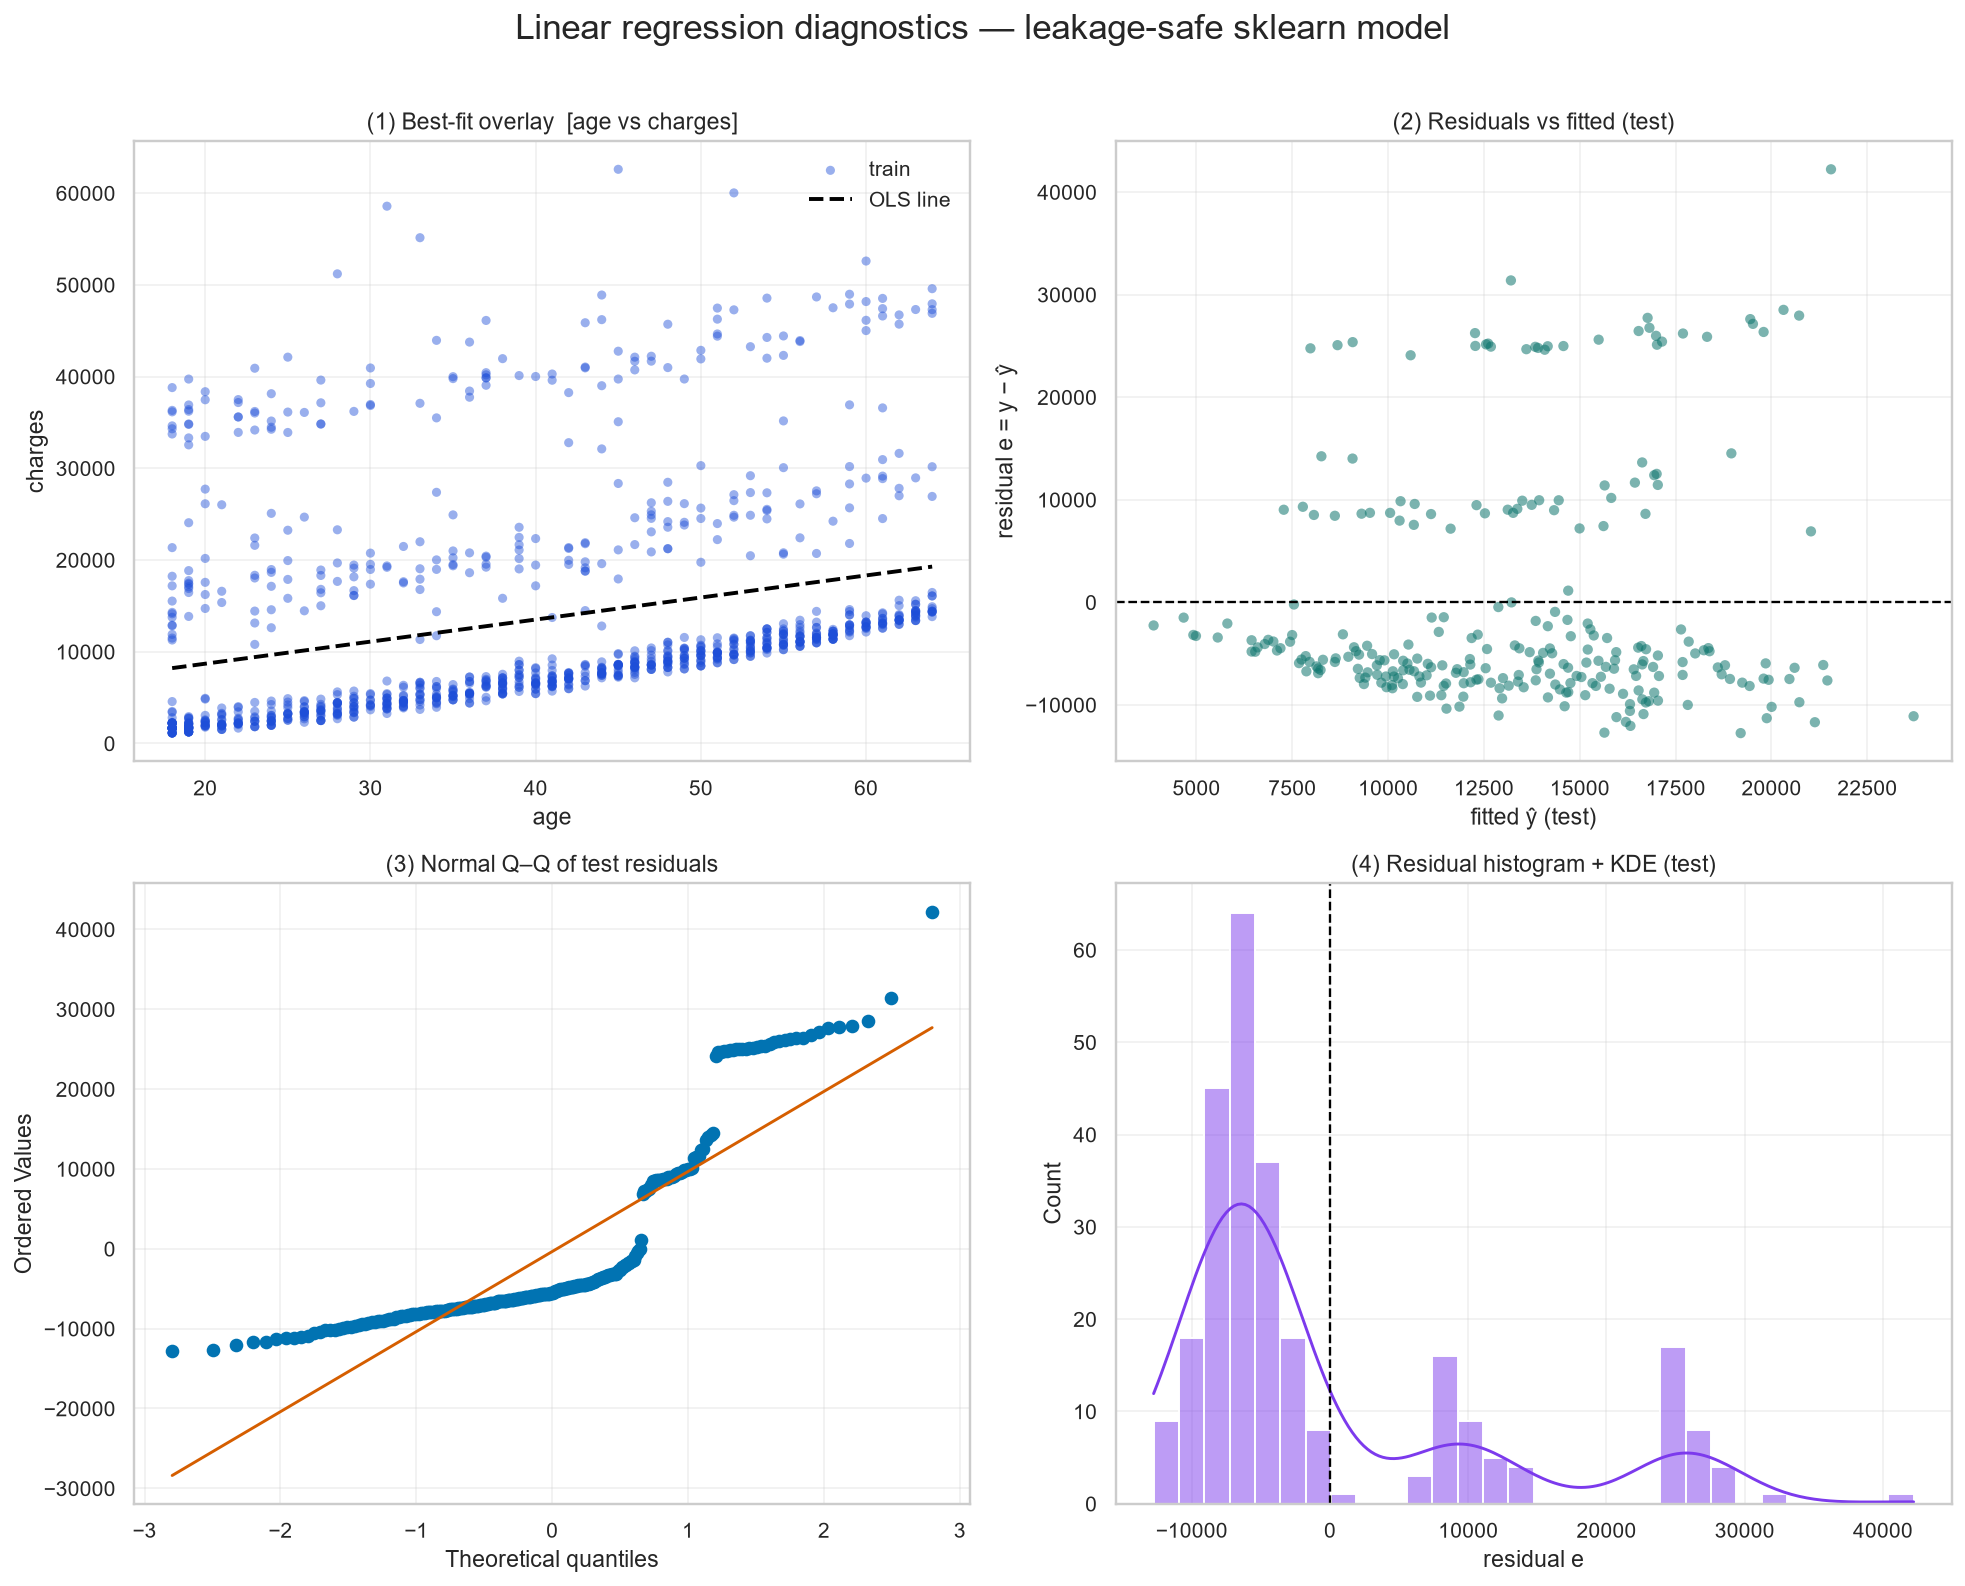

In [8]:
_banner("5 · 4-panel residual figure")

x1_tr = X_train[:, 0]
m1, c1 = np.polyfit(x1_tr, y_train, deg=1)  # why: univariate overlay for panel 1
x1_line = np.linspace(x1_tr.min(), x1_tr.max(), 80)

e_te = y_test - yhat_te  # why: test residual = leftover on unseen rows
fitted_te = yhat_te

fig, axes = plt.subplots(2, 2, figsize=(14.2, 11.2))
ax1, ax2, ax3, ax4 = axes.ravel()

# (1) best-fit line overlay on the first configured feature
ax1.scatter(x1_tr, y_train, s=22, alpha=0.45, c="#1d4ed8", edgecolors="none", label="train")
ax1.plot(x1_line, c1 + m1 * x1_line, ls="--", c="black", lw=2, label="OLS line")
ax1.set_xlabel(FEATURE_COLUMNS[0])
ax1.set_ylabel(TARGET_COLUMN)
ax1.set_title(f"(1) Best-fit overlay  [{FEATURE_COLUMNS[0]} vs {TARGET_COLUMN}]")
ax1.legend(frameon=False)

# (2) residuals vs fitted
ax2.scatter(fitted_te, e_te, s=28, alpha=0.55, c="#0f766e", edgecolors="none")
ax2.axhline(0.0, color="black", ls="--", lw=1.2)  # why: 0 = no leftover
ax2.set_xlabel("fitted ŷ (test)")
ax2.set_ylabel("residual e = y − ŷ")
ax2.set_title("(2) Residuals vs fitted (test)")

# (3) Normal Q-Q
stats.probplot(e_te, dist="norm", plot=ax3)  # why: compare residual quantiles to N(0,σ²)
ax3.set_title("(3) Normal Q–Q of test residuals")

# (4) histogram + KDE
sns.histplot(e_te, kde=True, ax=ax4, color="#7c3aed", edgecolor="white", bins=30)
ax4.axvline(0.0, color="black", ls="--", lw=1.2)
ax4.set_xlabel("residual e")
ax4.set_title("(4) Residual histogram + KDE (test)")

fig.suptitle("Linear regression diagnostics — leakage-safe sklearn model", y=1.01)
fig.tight_layout()
plt.show()


## 6. Viva-voce (indicative Q&A)

**Q1. Write the OLS normal equations.**  
**A.** $X^{\top}X\,\hat\beta=X^{\top}y$, or $\hat\beta=(X^{\top}X)^{-1}X^{\top}y$ when $X^{\top}X$ is invertible. Prefer `solve` / SVD, not `inv`.

**Q2. What is a residual?**  
**A.** $e_i=y_i-\hat{y}_i$. OLS minimises $\sum e_i^{2}$.

**Q3. Define $SS_{\mathrm{res}}$, $SS_{\mathrm{tot}}$, and $R^2$.**  
**A.** $SS_{\mathrm{res}}=\sum e_i^{2}$, $SS_{\mathrm{tot}}=\sum(y_i-\bar{y})^{2}$, $R^{2}=1-SS_{\mathrm{res}}/SS_{\mathrm{tot}}$.

**Q4. Why divide covariance by $n-1$ in Practical 02 but use $n$ in some GD notes?**  
**A.** Different losses. OLS RSS does not divide; MSE often uses $1/n$ or $1/(2n)$ only to scale the gradient. The **minimiser** $\hat\beta$ is the same.

**Q5. Write one GD update for linear MSE.**  
**A.** $\beta\leftarrow\beta-\eta\cdot\frac{1}{n}X^{\top}(X\beta-y)$.

**Q6. Name four assumptions we plotted for.**  
**A.** Linearity, homoscedasticity, normality of residuals, independence.

**Q7. Which of those is *not* required for Gauss–Markov BLUE?**  
**A.** Normality. BLUE needs linear unbiased + spherical errors. Normality is for exact $t$ tests.

**Q8. Why `StandardScaler.fit` on the training set only?**  
**A.** $\mu$ and $\sigma$ are learned parameters. Using the test set leaks hold-out information into $X_{\mathrm{test}}$.

**Q9. MAE vs MSE vs RMSE?**  
**A.** MAE $=\frac{1}{n}\sum|e_i|$ (typical dollar miss). MSE $=\frac{1}{n}\sum e_i^{2}$ (squares). RMSE $=\sqrt{\mathrm{MSE}}$ (same units as $y$).

**Q10. Why adjusted $R^2$?**  
**A.** $R^{2}_{\mathrm{adj}}=1-(1-R^{2})\frac{n-1}{n-p-1}$ penalises extra predictors so you cannot “buy” $R^2$ with junk columns as easily.

**Q11. What does a fan in residuals vs fitted mean?**  
**A.** Heteroscedasticity — residual spread grows with $\hat{y}$. SEs and $p$-values from the homoscedastic model are untrustworthy.

**Q12. High train $R^2$, weak test RMSE — what happened?**  
**A.** Overfitting (or a bad split). Always quote **test** residual error in the lab record.


## 7. Conclusion

This practical locked in the **lab-manual loop** for linear regression:

1. **CONFIG first** — `DATA_PATH`, `FEATURE_COLUMNS`, `TARGET_COLUMN`, `DROP_COLUMNS`.
2. **Hand table** — $m$, $c$, $\hat{y}$, $e_i$, $SS_{\mathrm{res}}$, $SS_{\mathrm{tot}}$, $R^{2}$, checked against NumPy.
3. **Theory** — normal equations, GD update, four assumptions (linearity, homoscedasticity, residual normality, independence).
4. **sklearn** — split → train-only scale → `LinearRegression` → MAE / MSE / RMSE / $R^2$ / adjusted $R^2$.
5. **Pictures** — line overlay, residuals vs fitted, Q–Q, histogram+KDE.

**Next practical:** distance measures (Euclidean, Manhattan, cosine) — still without touching `extra/`.

### Submission checklist

- [ ] Re-run all cells on `ml-lab-kernel`
- [ ] Paste the 5-row totals ($m,c,SS_{\mathrm{res}},R^{2}$) in the lab record
- [ ] Record `load_origin`, `FEATURE_COLUMNS`, and **test** RMSE
